# 06 · Correlative alignment of two maps

Real multimodal work means overlaying maps that were **not** acquired on the
same pixel grid — a mechanical map and an imaging/chemistry map are shifted,
rotated and scaled relative to each other. Before you can say *"this mechanical
zone is that phase"* you must **register** them and then **quantify agreement**.

You will learn the exact pipeline from the tutorial, on **public data**:
1. **normalised cross-correlation (NCC)** as an alignment score,
2. recovering a **rigid transform** (rotation + translation),
3. **point-to-point agreement** and a **confusion matrix** between the two maps.

> We use two *real* channels of the Al–Cu map — hardness `H` and modulus `E` —
> and deliberately misalign one, so the ground-truth transform is known and the
> method can be checked. (No EBSD / proprietary data.)

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
from scipy.ndimage import shift as nd_shift
from skimage.transform import rotate
from skimage.registration import phase_cross_correlation

def z(a):
    m = np.isfinite(a); out = np.zeros_like(a, float)
    out[m] = (a[m] - a[m].mean()) / a[m].std(); return out
def ncc(a, b):                      # normalised cross-correlation in [-1,1]
    return float(np.mean(z(a) * z(b)))

## 1 · Two co-located channels
`H` and `E` are different measurements of the same area, both high in the hard intermetallic — so they are correlated and can be aligned to each other.

In [3]:
df = mm.load_map("alcu_2um")
A, ext = mm.map_to_grid(df, "H")            # modality A = mechanics (hardness)
B0, _  = mm.map_to_grid(df, "E")            # modality B = a second channel (modulus)
A = np.nan_to_num(A, nan=np.nanmean(A)); B0 = np.nan_to_num(B0, nan=np.nanmean(B0))
print("map size:", A.shape, " NCC(H,E) when perfectly aligned:", round(ncc(A, B0), 3))

map size: (200, 200)  NCC(H,E) when perfectly aligned: 0.838


## 2 · Misalign B by a known transform
Rotate + shift + add noise, as a second instrument would.

NCC after misalignment: 0.179  (was ~ 0.84 )


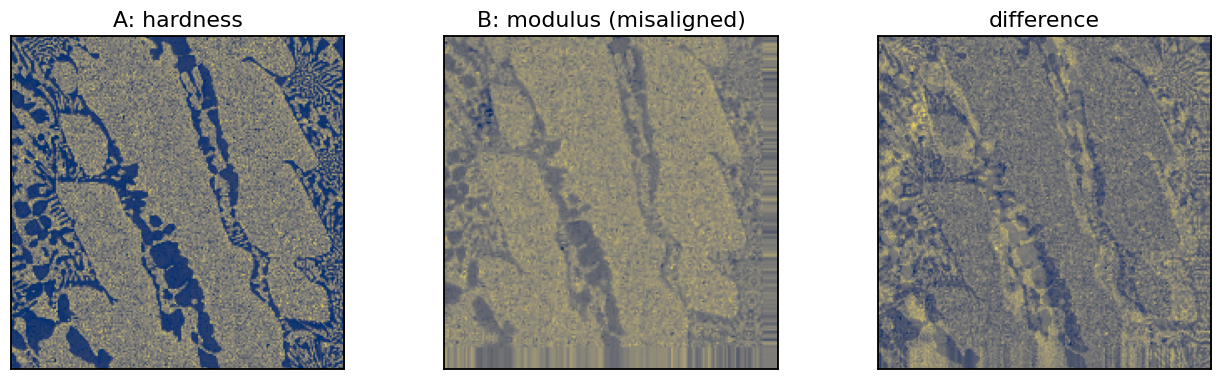

In [4]:
true_angle, true_shift = 6.0, (12, -8)          # ground truth (deg, (row,col) px)
B = rotate(B0, true_angle, order=1, mode="reflect", preserve_range=True)
B = nd_shift(B, true_shift, order=1, mode="nearest")
B = B + np.random.default_rng(0).normal(0, 0.05*B.std(), B.shape)
print("NCC after misalignment:", round(ncc(A, B), 3), " (was ~", round(ncc(A,B0),2), ")")
fig, ax = plt.subplots(1,3, figsize=(12,3.6))
for a,(img,t) in zip(ax, [(A,"A: hardness"),(B,"B: modulus (misaligned)"),(z(A)-z(B),"difference")]):
    im=a.imshow(img, origin="lower", cmap="cividis"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
fig.tight_layout()

## 3 · Recover the transform

A rigid transform = rotation + translation. We search a few candidate angles;
at each we get the best translation for free from **phase cross-correlation**
(an FFT trick), and keep the angle with the highest NCC.

In [5]:
best = (-1, 0.0, (0,0), None)
for ang in np.arange(-12, 12.1, 1.0):
    Br = rotate(B, -ang, order=1, mode="reflect", preserve_range=True)
    sh, _, _ = phase_cross_correlation(A, Br, upsample_factor=10)
    Ba = nd_shift(Br, sh, order=1, mode="nearest")
    s = ncc(A, Ba)
    if s > best[0]: best = (s, ang, tuple(np.round(sh,1)), Ba)
score, ang, sh, B_reg = best
print(f"recovered angle = {ang:.1f} deg (true {true_angle}),  shift = {sh} (true {true_shift})")
print(f"NCC: misaligned {ncc(A,B):.2f}  ->  registered {score:.2f}")

recovered angle = 6.0 deg (true 6.0),  shift = (np.float64(-11.1), np.float64(9.1)) (true (12, -8))
NCC: misaligned 0.18  ->  registered 0.71


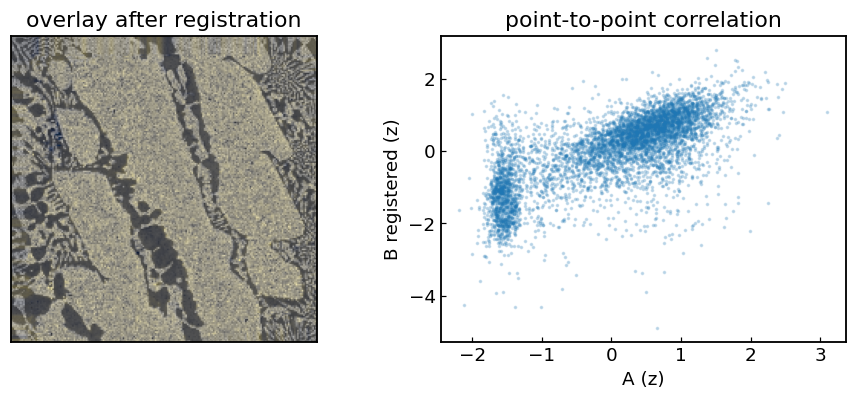

In [6]:
fig, ax = plt.subplots(1,2, figsize=(8.4,3.8))
ax[0].imshow(A, origin="lower", cmap="Greys_r"); ax[0].imshow(B_reg, origin="lower", cmap="cividis", alpha=0.5)
ax[0].set_title("overlay after registration"); ax[0].set_xticks([]); ax[0].set_yticks([])
ax[1].scatter(z(A).ravel()[::7], z(B_reg).ravel()[::7], s=2, alpha=0.2)
ax[1].set_xlabel("A (z)"); ax[1].set_ylabel("B registered (z)"); ax[1].set_title("point-to-point correlation")
fig.tight_layout()

## 4 · Point-to-point agreement

Turn each aligned map into a **two-phase label** (hard vs soft, split at the
median) and cross-tabulate. The **agreement %** and **confusion matrix** are
exactly what you report for a multimodal correlation.

point-to-point agreement = 79.7%   hard-phase Dice = 0.80


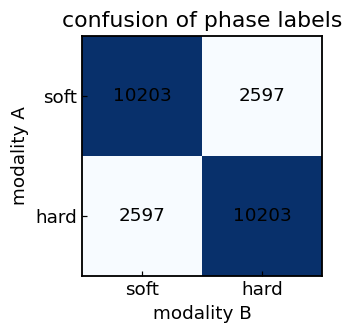

In [7]:
crop = (slice(20,180), slice(20,180))                # ignore rotation border
la = (A[crop] > np.median(A[crop])).astype(int)
lb = (B_reg[crop] > np.median(B_reg[crop])).astype(int)
agree = float((la == lb).mean()) * 100
cm = np.array([[int(((la==i)&(lb==j)).sum()) for j in (0,1)] for i in (0,1)])
dice = 2*cm[1,1] / (2*cm[1,1] + cm[0,1] + cm[1,0])
print(f"point-to-point agreement = {agree:.1f}%   hard-phase Dice = {dice:.2f}")
fig, ax = plt.subplots(figsize=(3.4,3.2)); im=ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1],["soft","hard"]); ax.set_yticks([0,1],["soft","hard"])
ax.set_xlabel("modality B"); ax.set_ylabel("modality A")
for (i,j),v in np.ndenumerate(cm): ax.text(j,i,f"{v}",ha="center",va="center")
ax.set_title("confusion of phase labels"); fig.tight_layout()

## Recap
- **NCC** scores how well two maps overlap; **phase cross-correlation** recovers
  the translation, and a small **angle search** handles rotation (an affine fit
  adds scale/shear — same idea, more parameters).
- After registration, **agreement %** and a **confusion matrix** quantify how
  well two modalities tell the same story — the honest output of any correlative
  workflow.

This closes the unsupervised → supervised → multimodal arc on public data.